# Figure 5: Immune–mutation axis

This notebook reproduces Figure 5 of the manuscript.

The figure uses fitted cancer-incidence model parameters from the subtype fits generated in the Figure 4 notebook. For each cancer subtype, we decompose the modeled increase in cancer risk between ages 40 and 70 into:

- an immune-associated component, \(I_c\)
- a mutation-associated component, \(M_c\)

The main points correspond to the primary latency offset, \(t_\mathrm{off}=5\) years. Open markers show sensitivity to \(t_\mathrm{off}=0\) and \(t_\mathrm{off}=10\) years.

The notebook expects the following files in the same directory:

- `bootstrap_parameters_toff0_082025.csv`
- `bootstrap_parameters_toff5_082125.csv`
- `bootstrap_parameters_toff10_082025.csv`
- `TCR_size_diversity_age_sex.csv`

The `bootstrap_parameters...csv` files are summary files from the Figure 4 fitting workflow. They contain the original-data best-fit parameters and bootstrap-derived uncertainties.

In [1]:
# ============================================================
# Imports and plotting defaults
# ============================================================

import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.interpolate import CubicSpline, interp1d
from matplotlib.ticker import LogLocator, FuncFormatter
from matplotlib.lines import Line2D

%config InlineBackend.figure_format = "png"

plt.rcParams["xtick.labelsize"] = 12
plt.rcParams["ytick.labelsize"] = 12
plt.rcParams["axes.labelsize"] = 14

RANDOM_SEED = 1
np.random.seed(RANDOM_SEED)

In [2]:
# ============================================================
# File configuration
# ============================================================

# Parameter summary files produced by the Figure 4 notebook.
PARAMETER_FILE_TOFF0 = "bootstrap_parameters_toff0_082025.csv"
PARAMETER_FILE_TOFF5 = "bootstrap_parameters_toff5_082125.csv"
PARAMETER_FILE_TOFF10 = "bootstrap_parameters_toff10_082025.csv"

# Public TCR repertoire table.
TCR_FILE = "TCR_size_diversity_age_sex.csv"
TCR_URL = "https://zenodo.org/records/13993996/files/TCR_size_diversity_age_sex.csv?download=1"

# Figure output.
SAVE_FIGURE = False
FIGURE_FILE = "fig5.pdf"

In [3]:
# ============================================================
# Load TCR repertoire data
# ============================================================
#
# Figure 5 needs the population median TCR diversity as a function of age.
# This is used to evaluate the immune component at ages 40 and 70.
#
# Use the local file if present; otherwise read directly from Zenodo.

if os.path.exists(TCR_FILE):
    tcr_path = TCR_FILE
else:
    tcr_path = TCR_URL

df_features_pd = (
    pd.read_csv(tcr_path)
    .rename(
        columns={
            "#Subject_ID": "Subject_ID",
            " age": "age",
            " sex": "sex",
            " size": "ntemplates",
            " diversity": "nur",
        }
    )
)

df_features_pd["sex"] = df_features_pd["sex"].str.strip().str.lower()

df_features_pd.head()

,Subject_ID,age,sex,ntemplates,nur
0,30000,63,male,508139,274815
1,30001,76,female,263716,167611
2,30002,70,female,519416,261836
3,30003,44,male,576294,383460
4,30004,47,male,505447,290642


In [4]:
# ============================================================
# Binned-median helper
# ============================================================
#
# This is the same binned-median helper used in the original manuscript
# notebooks. For Figure 5, we use it to estimate the median TCR diversity
# curve across all subjects.

def bootbin_median(
    _x,
    _y,
    nbins=20,
    nreal=1001,
    ci=[0.1, 0.9],
    bins=None,
    do_mean=False,
    do_sum=False,
    plot_bootbin=False,
):
    """
    Compute binned medians, bootstrap errors, and central intervals.

    Parameters
    ----------
    _x, _y : array-like
        Input x and y values.
    nbins : int
        Number of equal-count bins if explicit bins are not provided.
    nreal : int
        Number of bootstrap realizations for uncertainty on the median.
    ci : list
        Lower and upper quantiles for central intervals.
    bins : list of tuple or None
        Explicit bins as [lower, upper) intervals.
    do_mean, do_sum : bool
        Alternate aggregation modes retained from the original code.
    plot_bootbin : bool
        If True, plot the binned result.

    Returns
    -------
    dict
        Dictionary with xmed, ymed, yerr, ci_lo, ci_hi, and yres.
    """
    good_index = np.where(np.isfinite(_x) & np.isfinite(_y))[0]

    x = np.asarray(_x)[good_index]
    y = np.asarray(_y)[good_index]

    ss = np.argsort(x)
    xss = x[ss]
    yss = y[ss]

    if bins is None:
        x_split = np.array_split(xss, nbins)
        y_split = np.array_split(yss, nbins)
    else:
        x_split = []
        y_split = []

        for bi in bins:
            in_bin = np.where((xss >= bi[0]) & (xss < bi[1]))[0]

            if len(in_bin) > 1:
                x_split.append(xss[in_bin])
                y_split.append(yss[in_bin])

    if do_mean:
        agg_func_x = np.mean
        agg_func_y = np.mean
    elif do_sum:
        agg_func_x = np.median
        agg_func_y = np.sum
    else:
        agg_func_x = np.median
        agg_func_y = np.median

    xmed = np.asarray([agg_func_x(xi) for xi in x_split])
    ymed = np.asarray([agg_func_y(yi) for yi in y_split])

    yres = np.asarray(
        [
            yj
            for yi in y_split
            for yj in yi - agg_func_y(yi)
        ]
    )

    ci_lo = np.asarray(
        [
            interp1d(
                np.linspace(0, 1, num=len(yi)),
                np.sort(yi),
            )(ci[0])
            for yi in y_split
        ]
    )

    ci_hi = np.asarray(
        [
            interp1d(
                np.linspace(0, 1, num=len(yi)),
                np.sort(yi),
            )(ci[1])
            for yi in y_split
        ]
    )

    if not do_sum:
        yboot = [
            [
                agg_func_y(
                    yi[np.random.randint(0, high=len(yi), size=len(yi))]
                )
                for yi in y_split
            ]
            for _ in range(nreal)
        ]

        yerr = np.asarray(
            [
                np.nanstd(yi)
                for yi in np.asarray(yboot).T
            ]
        )
    else:
        yerr = np.sqrt(ymed)

    if plot_bootbin:
        plt.figure(figsize=(10, 7))
        plt.fill_between(xmed, ci_lo, ci_hi, alpha=0.2)
        plt.errorbar(xmed, ymed, yerr=yerr)

    return {
        "xmed": xmed,
        "ymed": ymed,
        "yres": yres,
        "yerr": yerr,
        "ci_lo": ci_lo,
        "ci_hi": ci_hi,
    }

In [5]:
# ============================================================
# Build population median TCR diversity curve
# ============================================================
#
# Figure 5 uses the overall median TCR diversity curve, not sex-specific
# curves. This matches the original notebook.
#
# The model parameters are subtype specific, while the immune component
# here is evaluated using the median population diversity at ages 40 and 70.

b1 = np.arange(9) * 10
b2 = np.arange(9) * 10 + 10
b2[-1] = 100

age_bins = [(lo, hi) for lo, hi in zip(b1, b2)]

central_68 = [0.16, 0.84]

tcr_median = bootbin_median(
    df_features_pd["age"].values,
    df_features_pd["nur"].values,
    bins=age_bins,
    ci=central_68,
)

median_tcr_diversity = CubicSpline(
    tcr_median["xmed"],
    tcr_median["ymed"],
)

pd.DataFrame(
    {
        "age_median": tcr_median["xmed"],
        "median_tcr_diversity": tcr_median["ymed"],
        "error": tcr_median["yerr"],
    }
)

,age_median,median_tcr_diversity,error
0,18.0,419576.0,7543.099181
1,25.0,390374.0,4256.872202
2,36.0,357588.0,2088.854446
3,45.0,330338.5,1774.114225
4,54.0,313170.0,1834.080299
5,63.0,281470.0,1809.104284
6,73.0,238499.0,2774.563043
7,82.0,187849.0,10211.914274


In [6]:
# ============================================================
# Model decomposition helpers
# ============================================================
#
# For each cancer subtype, we evaluate the fitted model at ages 40 and 70.
#
# The model is:
#
#   I(t, D) = A * (t - t_off)^gamma * exp[-D(t) / D0] * L(t)
#
# where L(t) is the late-age logistic suppression term.
#
# For Figure 5, we plot:
#
#   M_c = mutation_component(70) / mutation_component(40)
#   I_c = immune_component(70) / immune_component(40)
#
# The logistic term is included in the total risk ratio but not in M_c or I_c.
# This follows the original notebook logic.

def logistic_decay(age, k, t0):
    """
    Late-age logistic suppression term.
    """
    return 1 / (1 + np.exp(-k * (age - t0)))


def model_components_for_risk_ratio(age, A, gamma, D0, k, t0, toff):
    """
    Evaluate total risk, mutation component, and immune component.

    Parameters
    ----------
    age : array-like
        Ages at which to evaluate the model.
    A, gamma, D0, k, t0 : float
        Fitted model parameters.
    toff : float
        Latency offset.

    Returns
    -------
    total_risk, mutation_component, immune_component : np.ndarray
        Model components evaluated at each age.
    """
    age = np.asarray(age)

    logistic_component = logistic_decay(age, k, t0)

    immune_component = np.exp(
        -median_tcr_diversity(age) / D0
    )

    mutation_component = (age - toff) ** gamma

    total_risk = (
        A
        * immune_component
        * mutation_component
        * logistic_component
    )

    return total_risk, mutation_component, immune_component


def compute_risk_decomposition(names, params_array, toff):
    """
    Compute age 40-to-70 risk decomposition for all cancer subtypes.

    Parameters
    ----------
    names : list
        Cancer subtype names.
    params_array : np.ndarray
        Parameter matrix with columns:
        A, gamma, D0, k, t0.
    toff : int or float
        Latency offset.

    Returns
    -------
    pd.DataFrame
        Columns:
        cancer, risk_ratio, immune, mutation, relative_risk_ratio.
    """
    age = np.asarray([40, 70])

    rows = []

    for i, cancer_name in enumerate(names):
        total_risk, mutation_component, immune_component = (
            model_components_for_risk_ratio(
                age,
                *params_array[i, :],
                toff=toff,
            )
        )

        risk_ratio = total_risk[1] / total_risk[0]
        immune_ratio = immune_component[1] / immune_component[0]
        mutation_ratio = mutation_component[1] / mutation_component[0]
        relative_risk_ratio = immune_ratio / mutation_ratio

        rows.append(
            {
                "cancer": cancer_name,
                "risk_ratio": risk_ratio,
                "immune": immune_ratio,
                "mutation": mutation_ratio,
                "relative_risk_ratio": relative_risk_ratio,
            }
        )

    return pd.DataFrame(rows)

In [7]:
# ============================================================
# Load fitted parameter files
# ============================================================
#
# The parameter CSVs are bootstrap-summary files. For Figure 5 we use only
# the original-data best-fit columns:
#
#   A_orig, gamma_orig, R0_orig, k_orig, t0_orig
#
# R0 is equivalent to D0 in the manuscript notation.

def load_params_and_names(csv_path):
    """
    Load cancer names and original-data best-fit parameters.

    The returned parameter order is:
        A, gamma, D0, k, t0

    This order matches model_components_for_risk_ratio().
    """
    df = pd.read_csv(csv_path)

    # The original files may use either 'site' or '#site'.
    if "site" in df.columns:
        label_col = "site"
    elif "#site" in df.columns:
        label_col = "#site"
    else:
        # Fallback: first non-numeric column.
        label_col = None
        for col in df.columns:
            if not pd.api.types.is_numeric_dtype(df[col]):
                label_col = col
                break

        if label_col is None:
            raise ValueError(f"No cancer-name column found in {csv_path}")

    required_cols = ["A_orig", "gamma_orig", "R0_orig", "k_orig", "t0_orig"]

    missing_cols = [col for col in required_cols if col not in df.columns]
    if missing_cols:
        raise ValueError(
            f"{csv_path} is missing required columns: {missing_cols}"
        )

    names = df[label_col].tolist()
    params = df[required_cols].to_numpy(dtype=float)

    return names, params


def drop_aggregate_row(names, params):
    """
    Remove aggregate/all-sites rows if present.

    The Figure 5 immune-mutation axis uses only the 18 subtype fits.
    """
    keep = []

    for i, name in enumerate(names):
        cleaned = str(name).strip().lower()

        if cleaned in {
            "all sites",
            "aggregated cancers",
            "aggregated cancers initial selection",
            "aggregated_cancers_initial_selection",
        }:
            continue

        keep.append(i)

    names_keep = [names[i] for i in keep]
    params_keep = params[keep]

    return names_keep, params_keep


names0, params0 = load_params_and_names(PARAMETER_FILE_TOFF0)
names5, params5 = load_params_and_names(PARAMETER_FILE_TOFF5)
names10, params10 = load_params_and_names(PARAMETER_FILE_TOFF10)

names0, params0 = drop_aggregate_row(names0, params0)
names5, params5 = drop_aggregate_row(names5, params5)
names10, params10 = drop_aggregate_row(names10, params10)

print(f"t_off=0:  {len(names0)} cancer subtypes")
print(f"t_off=5:  {len(names5)} cancer subtypes")
print(f"t_off=10: {len(names10)} cancer subtypes")

t_off=0:  18 cancer subtypes
t_off=5:  18 cancer subtypes
t_off=10: 18 cancer subtypes


In [8]:
# ============================================================
# Validate and align cancer subtype order across latency files
# ============================================================
#
# Figure 5 overlays points from t_off = 0, 5, and 10 years.
# To do this safely, all three parameter files must refer to the same
# set of cancer subtypes.
#
# We align the t_off = 0 and t_off = 10 parameter arrays to the order
# of the primary t_off = 5 file.

def align_parameters_to_reference(reference_names, target_names, target_params):
    """
    Reorder target_params so that target_names match reference_names.

    Parameters
    ----------
    reference_names : list
        Desired cancer subtype order.
    target_names : list
        Names corresponding to target_params.
    target_params : np.ndarray
        Parameter matrix to reorder.

    Returns
    -------
    np.ndarray
        target_params reordered to match reference_names.
    """
    target_lookup = {
        name: i
        for i, name in enumerate(target_names)
    }

    missing = [
        name for name in reference_names
        if name not in target_lookup
    ]

    if missing:
        raise ValueError(
            f"Missing cancer subtypes in target parameter file: {missing}"
        )

    aligned_indices = [
        target_lookup[name]
        for name in reference_names
    ]

    return target_params[aligned_indices]


params0_aligned = align_parameters_to_reference(
    names5,
    names0,
    params0,
)

params10_aligned = align_parameters_to_reference(
    names5,
    names10,
    params10,
)

# Use the t_off = 5 order as the canonical order for Figure 5.
cancer_names = names5
params5_aligned = params5

print("Aligned parameter files successfully.")
print(f"N cancer subtypes: {len(cancer_names)}")
print("\nCancer subtype order:")
for name in cancer_names:
    print(f"  {name}")

Aligned parameter files successfully.
N cancer subtypes: 18

Cancer subtype order:
  Acute myeloid leukemia
  Chronic lymphocytic leukemia
  Chronic myeloid leukemia
  Diffuse large B cell lymphoma
  Follicular lymphoma
  Multiple myeloma
  Lung adenocarcinoma
  Lung squamous cell carcinoma
  Small cell lung carcinoma
  Kidney clear cell carcinoma
  Kidney papillary carcinoma
  Kidney chromophobe carcinoma
  Colorectal adenocarcinoma
  Gastric adenocarcinoma
  Pancreatic adenocarcinoma
  Melanoma of skin
  Malignant gliomas
  Soft tissue sarcomas


In [9]:
# ============================================================
# Compute Figure 5 risk decompositions
# ============================================================
#
# The primary figure uses t_off = 5.
# Sensitivity overlays use t_off = 0 and t_off = 10.

risk_decomposition_toff0 = compute_risk_decomposition(
    cancer_names,
    params0_aligned,
    toff=0,
)

risk_decomposition_toff5 = compute_risk_decomposition(
    cancer_names,
    params5_aligned,
    toff=5,
)

risk_decomposition_toff10 = compute_risk_decomposition(
    cancer_names,
    params10_aligned,
    toff=10,
)

risk_decomposition_toff5.sort_values(
    "relative_risk_ratio",
    ascending=False,
)

,cancer,risk_ratio,immune,mutation,relative_risk_ratio
10,Kidney papillary carcinoma,13.519584,16.156632,2.051794,7.874391
15,Melanoma of skin,5.733604,3.965728,1.807260,2.194331
2,Chronic myeloid leukemia,3.273333,2.562874,1.293046,1.982044
13,Gastric adenocarcinoma,12.726860,5.630784,3.073100,1.832281
17,Soft tissue sarcomas,4.192039,2.697717,1.571626,1.716514
16,Malignant gliomas,5.897564,2.737866,2.347584,1.166248
0,Acute myeloid leukemia,6.978726,2.841483,2.456017,1.156947
9,Kidney clear cell carcinoma,9.177686,4.103369,4.627543,0.886727
11,Kidney chromophobe carcinoma,5.624302,2.640049,3.296541,0.800854
3,Diffuse large B cell lymphoma,7.803931,2.439670,3.199675,0.762474


In [10]:
# ============================================================
# Display labels and manuscript group definitions
# ============================================================

display_labels = {
    "acute myeloid leukemia": "AML",
    "chronic lymphocytic leukemia": "CLL",
    "chronic myeloid leukemia": "CML",
    "diffuse large b cell lymphoma": "DLBCL",
    "follicular lymphoma": "FL",
    "multiple myeloma": "MM",
    "colorectal adenocarcinoma": "CRC MSS",
    "gastric adenocarcinoma": "Gastric",
    "pancreatic adenocarcinoma": "PDAC",
    "lung adenocarcinoma": "LUAD",
    "lung squamous cell carcinoma": "LUSC",
    "small cell lung carcinoma": "SCLC",
    "kidney chromophobe carcinoma": "chRCC",
    "kidney clear cell carcinoma": "ccRCC",
    "kidney papillary carcinoma": "pRCC",
    "malignant gliomas": "Gliomas",
    "melanoma of skin": "Melanoma",
    "soft tissue sarcomas": "Sarcomas",
}

mutation_dominated_labels = {
    "small cell lung carcinoma",
    "lung adenocarcinoma",
    "pancreatic adenocarcinoma",
    "lung squamous cell carcinoma",
    "multiple myeloma",
    "chronic lymphocytic leukemia",
    "follicular lymphoma",
    "colorectal adenocarcinoma",
}

def normalize_cancer_name(name):
    return str(name).lower().replace("_", " ").replace("  ", " ").strip()

mutation_dominated = {
    cancer
    for cancer in cancer_names
    if normalize_cancer_name(cancer) in mutation_dominated_labels
}

immune_modulated = set(cancer_names) - mutation_dominated

print(f"Mutation-dominated: {len(mutation_dominated)}")
for cancer in cancer_names:
    if cancer in mutation_dominated:
        print(f"  {display_labels.get(normalize_cancer_name(cancer), cancer)}")

print(f"\nImmune-modulated: {len(immune_modulated)}")
for cancer in cancer_names:
    if cancer in immune_modulated:
        print(f"  {display_labels.get(normalize_cancer_name(cancer), cancer)}")

Mutation-dominated: 8
  CLL
  FL
  MM
  LUAD
  LUSC
  SCLC
  CRC MSS
  PDAC

Immune-modulated: 10
  AML
  CML
  DLBCL
  ccRCC
  pRCC
  chRCC
  Gastric
  Melanoma
  Gliomas
  Sarcomas


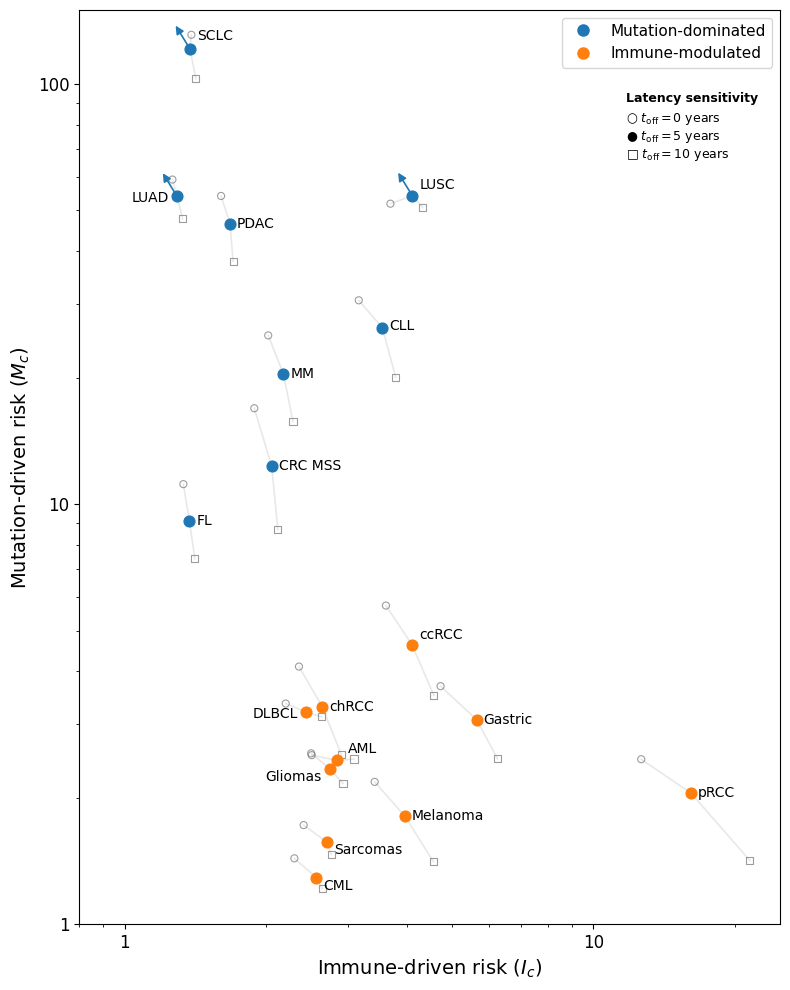

In [11]:
# ============================================================
# Plot Figure 5 using the original manuscript plotting logic
# ============================================================
#
# This cell uses the variables defined above:
#
#   risk_decomposition_toff0
#   risk_decomposition_toff5
#   risk_decomposition_toff10
#   cancer_names
#   normalize_cancer_name
#
# It follows the original plotting cell from manuscript_plots_public.ipynb:
#   - log-log axes
#   - grey latency trajectories
#   - open circle for t_off = 0
#   - filled circle for t_off = 5
#   - open square for t_off = 10
#   - mutation-dominated and immune-modulated color groups
#   - compact latency key inside the plot
#   - smoking-confounding arrows for lung cancers

import numpy as np
import matplotlib.pyplot as plt

from matplotlib.ticker import LogLocator, FuncFormatter
from matplotlib.lines import Line2D


# ------------------------------------------------------------
# Helper: short arrows indicating expected smoking-confounding shift
# ------------------------------------------------------------

def annotate_bias_arrows(
    ax,
    dfp,
    items=None,
    fx=0.85,
    fy=1.30,
    frac=0.45,
    lw=1.2,
    head_size=12,
    alpha=None,
    fallback_color="0.3",
    tol=1e-9,
    zorder=5,
):
    """
    Draw short up-left arrows from selected points on log-log axes.

    The color is taken from the scatter collection containing the point,
    matching the original plotting logic.
    """
    if items is None:
        items = [
            "Lung Small Cell Carcinoma",
            "Lung Adenocarcinoma",
            "Lung Squamous Cell Carcinoma",
        ]

    by_label = {
        str(lbl).strip(): (float(x), float(y))
        for lbl, x, y in zip(dfp["label"], dfp["immune"], dfp["mutation"])
    }

    def _find_collection_color(ax, x0, y0):
        for coll in ax.collections:
            offsets = np.asarray(coll.get_offsets())

            if offsets.ndim == 1:
                offsets = offsets.reshape(1, -1)

            if offsets.size == 0 or offsets.shape[1] < 2:
                continue

            mask = (
                np.isclose(offsets[:, 0], x0, rtol=0, atol=tol)
                & np.isclose(offsets[:, 1], y0, rtol=0, atol=tol)
            )

            if not mask.any():
                continue

            idx = np.flatnonzero(mask)[0]

            facecolors = coll.get_facecolors()

            if facecolors is None or len(facecolors) == 0:
                edgecolors = coll.get_edgecolors()
                color = edgecolors[0] if len(edgecolors) else fallback_color
            else:
                color = facecolors[0] if len(facecolors) == 1 else facecolors[idx]

            arrow_alpha = (
                alpha
                if alpha is not None
                else color[3]
                if isinstance(color, np.ndarray) and len(color) == 4
                else None
            )

            return color, arrow_alpha

        return fallback_color, alpha

    arrows = []

    for raw_label in items:
        label = str(raw_label).strip()

        if label not in by_label:
            continue

        x0, y0 = by_label[label]

        xt = x0 * fx
        yt = y0 * fy

        x1 = x0 + frac * (xt - x0)
        y1 = y0 + frac * (yt - y0)

        color, arrow_alpha = _find_collection_color(ax, x0, y0)

        ann = ax.annotate(
            "",
            xy=(x1, y1),
            xytext=(x0, y0),
            arrowprops=dict(
                arrowstyle="-|>",
                lw=lw,
                color=color,
                alpha=arrow_alpha,
                shrinkA=0,
                shrinkB=0,
                mutation_scale=head_size,
            ),
            zorder=zorder,
        )

        arrows.append(ann)

    return arrows


# ------------------------------------------------------------
# Helper: label placement
# ------------------------------------------------------------

def _place_labels_min_move_no_dupes(ax, pts):
    """
    Lightweight replacement for the original notebook label-placement helper.

    Most labels are placed just to the right of the point. A few labels are
    manually adjusted below to match the final manuscript layout.
    """
    manual_offsets = {
        "SCLC": (5, 4, "left", "bottom"),
        "LUSC": (5, 3, "left", "bottom"),
        "PDAC": (5, 0, "left", "center"),
        "CLL": (5, 1, "left", "center"),
        "MM": (5, 0, "left", "center"),
        "CRC MSS": (5, 0, "left", "center"),
        "FL": (5, 0, "left", "center"),
        "Gastric": (5, 0, "left", "center"),
        "ccRCC": (5, 2, "left", "bottom"),
        "pRCC": (5, 0, "left", "center"),
        "chRCC": (5, 0, "left", "center"),
        "CML": (5, -1, "left", "top"),
        "Melanoma": (5, 0, "left", "center"),
        "Sarcomas": (5, -1, "left", "top"),
    }

    for x, y, label in pts:
        dx, dy, ha, va = manual_offsets.get(
            label,
            (5, 2, "left", "bottom"),
        )

        ax.annotate(
            label,
            (x, y),
            xytext=(dx, dy),
            textcoords="offset points",
            ha=ha,
            va=va,
            fontsize=10,
        )


# ------------------------------------------------------------
# Build plotting DataFrames from the already-computed decompositions
# ------------------------------------------------------------

df5 = (
    risk_decomposition_toff5
    .set_index("cancer")
    .loc[cancer_names]
    .reset_index()
)

df0 = (
    risk_decomposition_toff0
    .set_index("cancer")
    .loc[cancer_names]
    .reset_index()
)

df10 = (
    risk_decomposition_toff10
    .set_index("cancer")
    .loc[cancer_names]
    .reset_index()
)


# ------------------------------------------------------------
# Labels and group assignments
# ------------------------------------------------------------

plot_label_map = {
    "acute myeloid leukemia": "AML",
    "acute myeloid leukemia aml": "AML",
    "chronic lymphocytic leukemia": "CLL",
    "chronic lymphocytic leukemia cll": "CLL",
    "chronic myeloid leukemia": "CML",
    "chronic myeloid leukemia cml": "CML",
    "colorectal adenocarcinoma": "CRC MSS",
    "colorectal adenocarcinoma mss": "CRC MSS",
    "diffuse large b cell lymphoma": "DLBCL",
    "diffuse large b cell lymphoma dlbcl": "DLBCL",
    "follicular lymphoma": "FL",
    "gastric adenocarcinoma": "Gastric",
    "kidney chromophobe carcinoma": "chRCC",
    "kidney clear cell carcinoma": "ccRCC",
    "kidney papillary carcinoma": "pRCC",
    "lung adenocarcinoma": "LUAD",
    "lung squamous cell carcinoma": "LUSC",
    "malignant gliomas": "Gliomas",
    "malignant gliomas astrocytic tumors": "Gliomas",
    "melanoma of skin": "Melanoma",
    "melanoma": "Melanoma",
    "multiple myeloma": "MM",
    "pancreatic adenocarcinoma": "PDAC",
    "small cell lung carcinoma": "SCLC",
    "lung small cell carcinoma": "SCLC",
    "soft tissue sarcomas": "Sarcomas",
}

mutation_dominated_labels = {
    "CLL",
    "CRC MSS",
    "FL",
    "LUAD",
    "LUSC",
    "MM",
    "PDAC",
    "SCLC",
}

df5["plot_label"] = [
    plot_label_map.get(normalize_cancer_name(cancer), cancer)
    for cancer in df5["cancer"]
]

df5["group"] = np.where(
    df5["plot_label"].isin(mutation_dominated_labels),
    "Mutation-dominated",
    "Immune-modulated",
)


# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 10))

group_colors = {
    "Mutation-dominated": "tab:blue",
    "Immune-modulated": "tab:orange",
}

# Latency trajectories and sensitivity endpoints.
for i in range(len(df5)):
    ax.plot(
        [
            df0.iloc[i]["immune"],
            df5.iloc[i]["immune"],
            df10.iloc[i]["immune"],
        ],
        [
            df0.iloc[i]["mutation"],
            df5.iloc[i]["mutation"],
            df10.iloc[i]["mutation"],
        ],
        color="0.75",
        lw=1.2,
        zorder=1,
        alpha=0.35,
    )

    ax.scatter(
        df0.iloc[i]["immune"],
        df0.iloc[i]["mutation"],
        s=26,
        marker="o",
        facecolors="none",
        edgecolors="0.45",
        linewidths=0.8,
        alpha=0.7,
        zorder=2,
    )

    ax.scatter(
        df10.iloc[i]["immune"],
        df10.iloc[i]["mutation"],
        s=26,
        marker="s",
        facecolors="none",
        edgecolors="0.45",
        linewidths=0.8,
        alpha=0.7,
        zorder=2,
    )

# Main t_off = 5 points.
for group, sub in df5.groupby("group"):
    ax.scatter(
        sub["immune"],
        sub["mutation"],
        s=60,
        c=group_colors[group],
        label=group,
        zorder=3,
    )

# Axes.
ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlim(0.8, 25)
ax.set_ylim(1, 150)

ax.xaxis.set_major_locator(
    LogLocator(
        base=10.0,
        subs=(1.0,),
        numticks=10,
    )
)

ax.yaxis.set_major_locator(
    LogLocator(
        base=10.0,
        subs=(1.0,),
        numticks=10,
    )
)

ax.xaxis.set_major_formatter(
    FuncFormatter(
        lambda value, _: f"{int(value)}"
        if value in [1, 10, 20]
        else ""
    )
)

ax.yaxis.set_major_formatter(
    FuncFormatter(
        lambda value, _: f"{int(value)}"
        if value in [1, 10, 100]
        else ""
    )
)

ax.set_xlabel("Immune-driven risk ($I_c$)")
ax.set_ylabel("Mutation-driven risk ($M_c$)")


# ------------------------------------------------------------
# Labels
# ------------------------------------------------------------

manual_left = ["DLBCL", "Gliomas", "LUAD"]

pts = [
    (x, y, label)
    for x, y, label in zip(
        df5["immune"],
        df5["mutation"],
        df5["plot_label"],
    )
    if label not in manual_left + ["AML"]
]

_place_labels_min_move_no_dupes(ax, pts)

for _, row in df5.iterrows():
    label = row["plot_label"]

    if label in manual_left:
        ax.annotate(
            label,
            (row["immune"], row["mutation"]),
            xytext=(-6, -1),
            textcoords="offset points",
            ha="right",
            va="center" if label != "Gliomas" else "top",
            fontsize=10,
        )

    elif label == "AML":
        ax.annotate(
            label,
            (row["immune"], row["mutation"]),
            xytext=(8, 3),
            textcoords="offset points",
            ha="left",
            va="bottom",
            fontsize=10,
        )


# ------------------------------------------------------------
# Legend and latency key
# ------------------------------------------------------------

legend_handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        color="none",
        markerfacecolor=group_colors["Mutation-dominated"],
        markeredgecolor=group_colors["Mutation-dominated"],
        markersize=8,
        label="Mutation-dominated",
    ),
    Line2D(
        [0],
        [0],
        marker="o",
        color="none",
        markerfacecolor=group_colors["Immune-modulated"],
        markeredgecolor=group_colors["Immune-modulated"],
        markersize=8,
        label="Immune-modulated",
    ),
]

ax.legend(
    handles=legend_handles,
    frameon=True,
    fontsize=11,
    loc="upper right",
)

ax.text(
    0.78,
    0.91,
    "Latency sensitivity",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=9,
    fontweight="bold",
)

ax.text(
    0.78,
    0.89,
    r"○ $t_\mathrm{off}=0$ years" "\n"
    r"● $t_\mathrm{off}=5$ years" "\n"
    r"□ $t_\mathrm{off}=10$ years",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=9,
)


# ------------------------------------------------------------
# Smoking-related confounding arrows
# ------------------------------------------------------------

df5["label"] = [
    {
        "LUAD": "Lung Adenocarcinoma",
        "LUSC": "Lung Squamous Cell Carcinoma",
        "SCLC": "Lung Small Cell Carcinoma",
    }.get(label, label)
    for label in df5["plot_label"]
]

annotate_bias_arrows(
    ax,
    df5,
    fx=0.85,
    fy=1.30,
)

fig.tight_layout()

if SAVE_FIGURE:
    fig.savefig(FIGURE_FILE, bbox_inches="tight")

plt.show()